<a href="https://colab.research.google.com/github/nahlarashad/sentiment-analysis-system/blob/main/notebooks/sentiment_analysis_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =========================================
# Sentiment Analysis System
# IMDb Movie Reviews Dataset
# =========================================

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [4]:
# =========================================
# Load IMDb Dataset
# =========================================

VOCAB_SIZE = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\nExample Review:")
print(X_train[0])

print("\nLabel:")
print(y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Samples: 25000
Testing Samples: 25000

Example Review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283,

In [5]:
# =========================================
# Padding Sequences
# =========================================

MAX_LEN = 200

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Shape of Training Data:", X_train.shape)
print("Shape of Testing Data:", X_test.shape)

print("\nFirst Review After Padding:")
print(X_train[0])

Shape of Training Data: (25000, 200)
Shape of Testing Data: (25000, 200)

First Review After Padding:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4 

In [6]:
from tensorflow.keras.layers import Input

# =========================================
# Build Simple RNN Model
# =========================================

rnn_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    SimpleRNN(
        64,
        activation='tanh'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.5046 - loss: 0.6996 - val_accuracy: 0.5126 - val_loss: 0.6933
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6036 - loss: 0.6566 - val_accuracy: 0.5162 - val_loss: 0.6965
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6795 - loss: 0.5533 - val_accuracy: 0.5056 - val_loss: 0.7527
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7374 - loss: 0.4393 - val_accuracy: 0.5108 - val_loss: 0.8454
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7718 - loss: 0.3863 - val_accuracy: 0.5082 - val_loss: 0.8608


In [8]:
# =========================================
# Evaluate Simple RNN Model
# =========================================

rnn_loss, rnn_accuracy = rnn_model.evaluate(
    X_test,
    y_test
)

print("Simple RNN Test Accuracy:", rnn_accuracy)
print("Simple RNN Test Loss:", rnn_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5124 - loss: 0.8545
Simple RNN Test Accuracy: 0.512440025806427
Simple RNN Test Loss: 0.8545314073562622


Simple RNN struggled to capture long-term dependencies in long movie reviews, leading to poor generalization performance.

In [9]:
# =========================================
# Build LSTM Model
# =========================================

from tensorflow.keras.layers import Input

lstm_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,

    epochs=5,
    batch_size=128,

    validation_split=0.2,

    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.5207 - loss: 0.6916 - val_accuracy: 0.5222 - val_loss: 0.6882
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5926 - loss: 0.6707 - val_accuracy: 0.5372 - val_loss: 0.7739
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5971 - loss: 0.6510 - val_accuracy: 0.5910 - val_loss: 0.6406
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6654 - loss: 0.5974 - val_accuracy: 0.7022 - val_loss: 0.6158
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7994 - loss: 0.4687 - val_accuracy: 0.7872 - val_loss: 0.4879


In [11]:
# =========================================
# Evaluate LSTM Model
# =========================================

lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Test Accuracy:", lstm_accuracy)
print("LSTM Test Loss:", lstm_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7744 - loss: 0.5027
LSTM Test Accuracy: 0.7743600010871887
LSTM Test Loss: 0.5027468800544739


In [12]:
# =========================================
# Build GRU Model
# =========================================

gru_model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),

    GRU(64),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5052 - loss: 0.6932 - val_accuracy: 0.5182 - val_loss: 0.6917
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5768 - loss: 0.6913 - val_accuracy: 0.5188 - val_loss: 0.6880
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5946 - loss: 0.6482 - val_accuracy: 0.6638 - val_loss: 0.6548
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7799 - loss: 0.4659 - val_accuracy: 0.8346 - val_loss: 0.4021
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8956 - loss: 0.2794 - val_accuracy: 0.8678 - val_loss: 0.3337


In [14]:
# =========================================
# Evaluate GRU Model
# =========================================

gru_loss, gru_accuracy = gru_model.evaluate(
    X_test,
    y_test
)

print("GRU Test Accuracy:", gru_accuracy)
print("GRU Test Loss:", gru_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8511 - loss: 0.3710
GRU Test Accuracy: 0.8510800004005432
GRU Test Loss: 0.3710036277770996


In [15]:
results = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "Test Accuracy": [rnn_accuracy, lstm_accuracy, gru_accuracy],
    "Test Loss": [rnn_loss, lstm_loss, gru_loss]
})

results

,Model,Test Accuracy,Test Loss
0,Simple RNN,0.51244,0.854531
1,LSTM,0.77436,0.502747
2,GRU,0.85108,0.371004


In [16]:
gru_model.save("best_gru_model.keras")

In [17]:
from google.colab import files
files.download("best_gru_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# =========================================
# Prepare Word Index for Prediction Demo
# =========================================

word_index = imdb.get_word_index()

# Keras IMDb dataset reserves some indices
word_index = {word: (index + 3) for word, index in word_index.items()}

word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
# =========================================
# Prediction Function
# =========================================

def predict_sentiment(review):
    words = review.lower().split()

    encoded_review = []
    for word in words:
        encoded_review.append(word_index.get(word, 2))

    padded_review = pad_sequences(
        [encoded_review],
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    prediction = gru_model.predict(padded_review)[0][0]

    if prediction >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Prediction Score:", prediction)
    print("Predicted Sentiment:", sentiment)

In [20]:
predict_sentiment("This movie was amazing and the acting was great")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Review: This movie was amazing and the acting was great
Prediction Score: 0.9538747
Predicted Sentiment: Positive


In [21]:
predict_sentiment("The movie was boring and very bad")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Review: The movie was boring and very bad
Prediction Score: 0.041731715
Predicted Sentiment: Negative


In [22]:
# =========================================
# Correct vs Wrong Predictions Examples
# =========================================

y_pred_prob = gru_model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).reshape(-1)

correct_indices = np.where(y_pred == y_test)[0]
wrong_indices = np.where(y_pred != y_test)[0]

print("Number of Correct Predictions:", len(correct_indices))
print("Number of Wrong Predictions:", len(wrong_indices))

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Number of Correct Predictions: 21277
Number of Wrong Predictions: 3723


In [23]:
# =========================================
# Decode Reviews
# =========================================

reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    words = []
    for index in encoded_review:
        if index == 0:
            continue
        words.append(reverse_word_index.get(index, "?"))
    return " ".join(words)

In [24]:
# Show examples
for i in correct_indices[:3]:
    print("\nCorrect Prediction")
    print("Actual:", "Positive" if y_test[i] == 1 else "Negative")
    print("Predicted:", "Positive" if y_pred[i] == 1 else "Negative")
    print("Review:", decode_review(X_test[i]))

for i in wrong_indices[:3]:
    print("\nWrong Prediction")
    print("Actual:", "Positive" if y_test[i] == 1 else "Negative")
    print("Predicted:", "Positive" if y_pred[i] == 1 else "Negative")
    print("Review:", decode_review(X_test[i]))


Correct Prediction
Actual: Negative
Predicted: Negative
Review: <START> please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss

Correct Prediction
Actual: Positive
Predicted: Positive
Review: <START> this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances <UNK> the sandy dennis character apartment but the film builds to a disturbing climax br br the characters create an atmosphere <UNK> with sexual tension and psychological <UNK> it's very interesting that robert altman directed this considering the style and structure of his other films still the trademark altman audio style is evident 

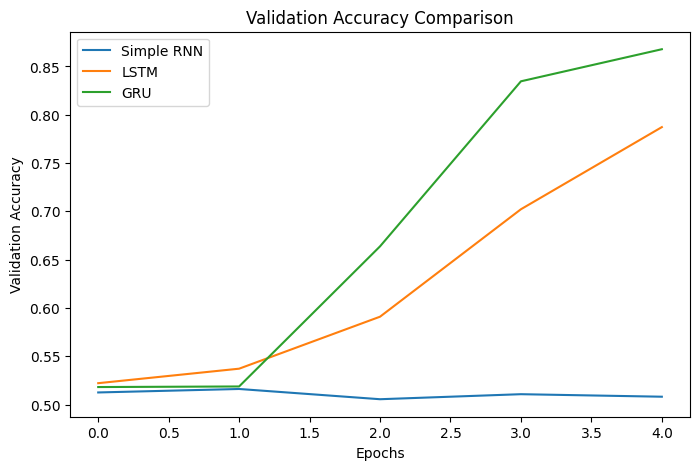

In [25]:
# =========================================
# Plot Accuracy
# =========================================

plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history['val_accuracy'], label='Simple RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

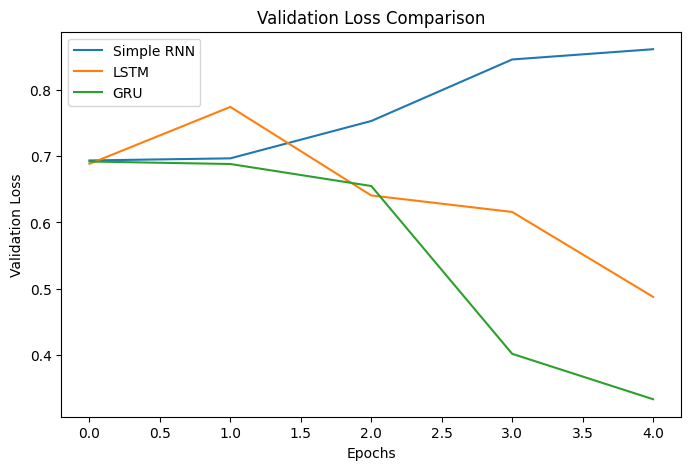

In [26]:
# =========================================
# Plot Loss
# =========================================

plt.figure(figsize=(8, 5))
plt.plot(history_rnn.history['val_loss'], label='Simple RNN')
plt.plot(history_lstm.history['val_loss'], label='LSTM')
plt.plot(history_gru.history['val_loss'], label='GRU')

plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()